In [1]:
import casadi as cs
import numpy as np
from collections import deque
from matplotlib import pyplot as plt
from scipy.linalg import null_space
from time import time
from copy import deepcopy
from matplotlib import pyplot as plt

np.set_printoptions(precision=4, suppress=True, linewidth=125)

In [2]:
N_F = 25
N_S = 50
K = 40
W = cs.sqrt(10)
N_BRANCH = 5
N_STEPS = 100
N_NEWTON = 10
STEP_SIZE = 0.01
U0 = np.array(
    [0.0, 1.01, 0.0, 0.0, 0.0, 0.0, 0.00565685, 0.01525397, 0.00565685, 0.0, 1.01]
    # [0, 1.02334, 0.690765, -2.66782, -9.36157e-28, -1.42652, 0.0198692, 0.00669208, 0.0198692, 3.1187e-14, 4.58196]
)

In [3]:
xs = cs.SX.sym("xs", 4)
xf = cs.SX.sym("xf", 6)
xi = cs.SX.sym("xi")
dt = cs.SX.sym("dt")

l = cs.sqrt(xs[0] ** 2 + xs[1] ** 2)
Es = 0.5 * (xs[2] ** 2 + xs[3] ** 2) + xs[1] + 0.5 * (l - 1) ** 2
Ef = 0.5 * (xf[3] ** 2 + xf[4] ** 2) + xf[1]
dxs = cs.vertcat(
    xs[2:], K * (1 - l) * xs[0] / l, K * (1 - l) * xs[1] / l - 1
) + xi * cs.gradient(Es, xs)
dxf = cs.vertcat(xf[3:], 0, -1, -(W**2) * xf[2]) + xi * cs.gradient(Ef, xf)

ff = cs.Function("ff", [xf, xi], [dxf])
fs = cs.Function("fs", [xs, xi], [dxs])
energy_flight = cs.Function("energy_flight", [xf], [Ef])
energy_stance = cs.Function("energy_stance", [xs], [Es])

k1s = fs(xs, xi)
k1f = ff(xf, xi)
k2s = fs(xs + dt / 2 * k1s, xi)
k2f = ff(xf + dt / 2 * k1f, xi)
k3s = fs(xs + dt / 2 * k2s, xi)
k3f = ff(xf + dt / 2 * k2f, xi)
k4s = fs(xs + dt * k3s, xi)
k4f = ff(xf + dt * k3f, xi)
xs_ = xs + dt / 6 * (k1s + 2 * k2s + 2 * k3s + k4s)
xf_ = xf + dt / 6 * (k1f + 2 * k2f + 2 * k3f + k4f)

s2f = cs.vertcat(
    xs[:2], cs.atan(-xs[0] / xs[1]), xs[2:], (xs[0] * xs[3] - xs[1] * xs[2]) / l
)
f2s = cs.vertcat(-cs.sin(xf[2]), cs.cos(xf[2]), xf[3:5])

stance_to_flight = cs.Function("stance_to_flight", [xs], [s2f])
flight_to_stance = cs.Function("flight_to_stance", [xf], [f2s])
RK4s = cs.Function("RK4s", [xs, dt, xi], [xs_])
RK4f = cs.Function("RK4f", [xf, dt, xi], [xf_])

traj_f = RK4f.fold(N_F)
traj_s = RK4s.fold(N_S)
traj_f_list = RK4f.mapaccum(N_F)
traj_s_list = RK4s.mapaccum(N_S)

In [4]:
x_init = cs.SX.sym("x_init", 6)
t = cs.SX.sym("t", 3)
E = cs.SX.sym("E")
du1 = cs.SX.sym("du1", 11)
du2 = cs.SX.sym("du2", 11)
phi = cs.SX.sym("phi", 10)

z = cs.vertcat(x_init, t, xi)
u = cs.vertcat(z, E)

x_TD = traj_f(x_init, t[0], xi)
x_LO = traj_s(flight_to_stance(x_TD), t[1], xi)
x_apex = traj_f(stance_to_flight(x_LO), t[2], xi)

root = cs.vertcat(
    x_apex[1:] - x_init[1:],
    x_init[0],
    x_init[4],
    energy_flight(x_init) - E,
    cs.cos(x_TD[2]) - x_TD[1],
    x_LO[0] ** 2 + x_LO[1] ** 2 - 1,
)

J_root = cs.jacobian(root, z)
J_ext = cs.jacobian(root, u)
z_newton = z - cs.inv(J_root) @ root

b = du1.T @ cs.jtimes(J_ext, u, du2).T @ phi

newton_step = cs.Function("newton_step", [z, E], [z_newton])
compute_J = cs.Function("compute_J", [u], [J_ext])
residual = cs.Function("residual", [u], [root])
hessian = cs.Function("Hessian", [u, du1, du2, phi], [b])

newton = newton_step.fold(N_NEWTON)

In [5]:
opti = cs.Opti()
opti.solver(
    "ipopt", {"print_time": 0, "ipopt.print_level": 0, "ipopt.tol": 1e-12}
)

opti_u = opti.variable(11)
opti.subject_to(residual(opti_u) == 0)


In [6]:
def u2traj(u):
    x0,dt,xi = u[:6],u[6:9],u[9]
    traj1 = traj_f_list(x0, dt[0], xi)
    traj2 = stance_to_flight(
        traj_s_list(flight_to_stance(traj1[:, -1]), dt[1], xi)
    )
    traj3 = traj_f_list(traj2[:, -1], dt[2], xi)
    traj1[0, :] += traj2[0, 0] - traj1[0, -1]
    traj3[0, :] += traj2[0, -1] - traj3[0, 0]
    traj = cs.horzcat(traj1, traj2, traj3)
    return np.array(traj)

def process_bifurcation(u_, p1):
    u = cs.vertcat(newton(u_[:10],u_[10]),u_[10])
    J = compute_J(u)
    val, vec = np.linalg.eig(cs.vertcat(J, p1.T))
    idx_val = np.argmin(np.abs(val))
    p2 = vec[:, idx_val].real.reshape((11,1))
    p2 =  p2 - np.dot(p1.T,p2) * p1 
    p2 = p2 / np.linalg.norm(p2)
    val, vec = np.linalg.eig(J @ J.T)
    idx_val = np.argmin(np.abs(val))
    e = vec[:, idx_val].real
    b12 = hessian(u, p1, p2, e)
    b22 = hessian(u, p2, p2, e)
    beta2 = 1
    beta1 = -b22 / (2 * b12)
    p2 = beta1 * p1 + beta2 * p2
    p2 = p2 / np.linalg.norm(p2)
    return np.array(p2)


In [7]:
def unconstrained_continuation(u_current,p_current,d,N):
    is_bifurcation = False
    uh = []
    ph = []
    dh = []
    u_star,p1,p2 = None,None,None
    for step in range(N):
        u_current += np.sign(p_current[-1])*d*p_current.reshape((11,))
        opti.set_initial(opti_u,u_current)
        opti.solve()
        u_current = deepcopy(opti.value(opti_u))
        J = compute_J(u_current) 
        p_current = null_space(J)
        if np.linalg.det(cs.vertcat(J,p_current.T)) < 0:
            p_current = - p_current
        uh.append(u_current.copy())
        ph.append(p_current.copy())
        dh.append(np.linalg.det(cs.vertcat(J,p_current.T)))

        if step>2 and (ph[-2].T @ ph[-1])<0:
            coeff = dh[-2] / (dh[-2] + dh[-1])
            u_star = coeff * uh[-1] + (1-coeff) * uh[-2]
            p1 = coeff * ph[-1] - (1-coeff) * ph[-2]
            p2 = process_bifurcation(u_star,p1)
            is_bifurcation = True
            return uh,ph,dh,u_star,p1,p2,is_bifurcation
    return uh,ph,dh,u_star,p1,p2,is_bifurcation

In [ ]:
P0 = null_space(compute_J(U0)).reshape((11,))
to_explore = deque([(U0,P0)])
idx_branch = 0
components = []
deth = []

while to_explore and idx_branch < N_BRANCH:
    u_init,p_init = to_explore.popleft()
    uh,ph,dh,u_star,p1,p2,bifurcation = unconstrained_continuation(u_init,p_init,STEP_SIZE,N_STEPS)
    if bifurcation:
        to_explore.append((u_star,p1.copy()))
        to_explore.append((u_star,p2.copy()))
    components.append(uh)
    idx_branch += 1
    deth.append(dh)

[ 0.      1.1233  0.     -0.      0.     -0.      0.0199  0.0119  0.0199  0.      1.1233]
[ 0.      1.2718  0.     -0.      0.     -0.      0.0295  0.0113  0.0295  0.      1.2718]
[0.     1.2718 0.     0.     0.     0.     0.0295 0.0113 0.0295 0.     1.2718]


In [ ]:

uh,ph,dh,u_star,p1,p2,_ = unconstrained_continuation(U0,P0,0.01,100)
uh,ph,dh,u_star,p1,p2,_ = unconstrained_continuation(u_star,np.array(p1),0.01,100)
print(u_star,p2)
uh,ph,dh,u_star,p1,p2,_ = unconstrained_continuation(u_star,np.array(p2),0.01,100)


[ 0.      1.2718 -0.      0.      0.      0.      0.0295  0.0113  0.0295  0.      1.2718] [[-0.009 ]
 [ 0.0405]
 [ 0.    ]
 [ 0.6492]
 [ 0.0001]
 [ 0.7562]
 [ 0.0002]
 [-0.    ]
 [ 0.0026]
 [-0.0577]
 [ 0.0405]]


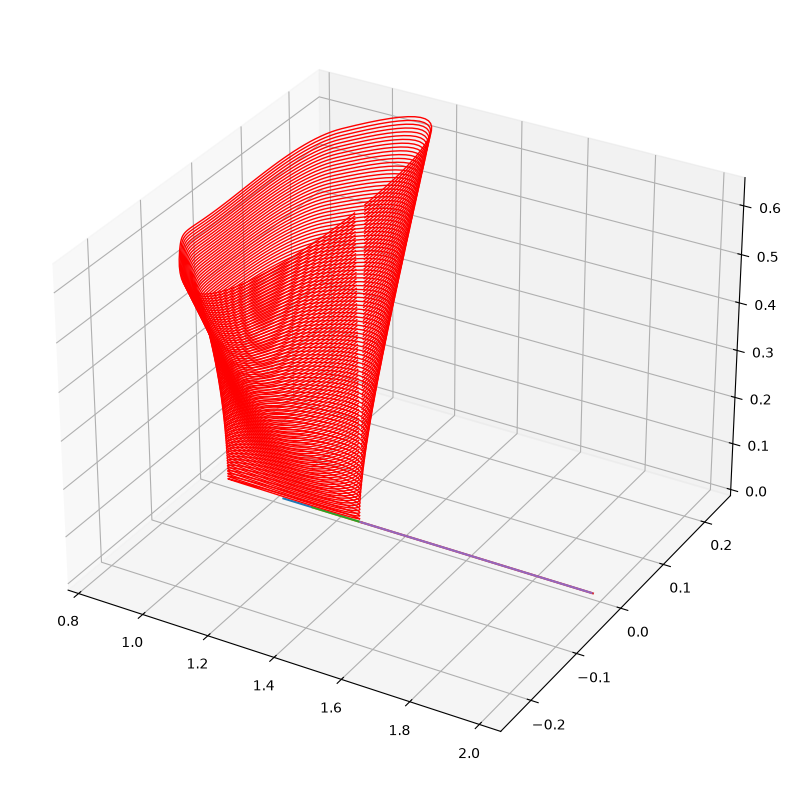

In [15]:
def plot_traj(ax,traj,c):
    ax.plot(traj[1,:],traj[2,:],traj[3,:], linewidth=1,color=c)

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(1,1,1,projection="3d")
for branch in components:
    branch = np.array(branch)
    plt.plot(branch[:,1],branch[:,2],branch[:,3])
for _u in uh:
    plot_traj(ax,u2traj(_u),'red')
# plt.plot(np.array(uh)[:,1],np.array(uh)[:,2],np.array(uh)[:,3])
# plt.plot(dh)
plt.show()